# Data Preprocessing

1. Load and explore the MovieLens 20M dataset
2. Clean the data and handle missing values
3. Filter out users/movies with too few ratings
4. Create efficient ID mappings
5. Split data into train/validation/test sets
6. Save everything for model training

## 1. Setup and Imports

In [23]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# For preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.5


## 2. Load the Data

In [24]:
# Define file paths
MOVIES_PATH = 'movie.csv'
RATINGS_PATH = 'rating.csv'

# Check if files exist
print("Checking file existence:")
print(f"Movies file exists: {os.path.exists(MOVIES_PATH)}")
print(f"Ratings file exists: {os.path.exists(RATINGS_PATH)}")

# Load movies data
print("\nLoading movies data...")
movies_df = pd.read_csv(MOVIES_PATH)
print(f"Movies dataset shape: {movies_df.shape}")

# Load ratings data
print("Loading ratings data...")
ratings_df = pd.read_csv(RATINGS_PATH)
print(f"Ratings dataset shape: {ratings_df.shape}")

print("\nData loaded successfully!")

Checking file existence:
Movies file exists: True
Ratings file exists: True

Loading movies data...
Movies dataset shape: (27278, 3)
Loading ratings data...
Ratings dataset shape: (20000263, 4)

Data loaded successfully!


## 3. Initial Inspection

In [ ]:

print("=== MOVIES DATA INSPECTION ===")
print(f"Shape: {movies_df.shape}")
print("\nFirst 5 rows:")
display(movies_df.head())

print("\nData types:")
print(movies_df.dtypes)

print("\nMissing values:")
print(movies_df.isnull().sum())

print("\nBasic statistics:")
print(movies_df.describe())

=== MOVIES DATA INSPECTION ===
Shape: (27278, 3)

First 5 rows:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Data types:
movieId     int64
title      object
genres     object
dtype: object

Missing values:
movieId    0
title      0
genres     0
dtype: int64

Basic statistics:
             movieId
count   27278.000000
mean    59855.480570
std     44429.314697
min         1.000000
25%      6931.250000
50%     68068.000000
75%    100293.250000
max    131262.000000


In [ ]:

print("=== RATINGS DATA INSPECTION ===")
print(f"Shape: {ratings_df.shape}")
print("\nFirst 5 rows:")
display(ratings_df.head())

print("\nData types:")
print(ratings_df.dtypes)

print("\nMissing values:")
print(ratings_df.isnull().sum())

print("\nBasic statistics:")
print(ratings_df.describe())

=== RATINGS DATA INSPECTION ===
Shape: (20000263, 4)

First 5 rows:


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40



Data types:
userId         int64
movieId        int64
rating       float64
timestamp     object
dtype: object

Missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Basic statistics:
             userId       movieId        rating
count  2.000026e+07  2.000026e+07  2.000026e+07
mean   6.904587e+04  9.041567e+03  3.525529e+00
std    4.003863e+04  1.978948e+04  1.051989e+00
min    1.000000e+00  1.000000e+00  5.000000e-01
25%    3.439500e+04  9.020000e+02  3.000000e+00
50%    6.914100e+04  2.167000e+03  3.500000e+00
75%    1.036370e+05  4.770000e+03  4.000000e+00
max    1.384930e+05  1.312620e+05  5.000000e+00


In [ ]:
# duplicates
print("=== DUPLICATE CHECK ===")
print(f"Duplicate movies: {movies_df.duplicated().sum()}")
print(f"Duplicate ratings: {ratings_df.duplicated().sum()}")

# Count unique values
print("\n=== UNIQUE COUNTS ===")
print(f"Unique movies: {movies_df['movieId'].nunique():,}")
print(f"Unique users: {ratings_df['userId'].nunique():,}")
print(f"Unique ratings: {len(ratings_df):,}")

# Rating distribution
print("\n=== RATING DISTRIBUTION ===")
print(ratings_df['rating'].value_counts().sort_index())

=== DUPLICATE CHECK ===
Duplicate movies: 0
Duplicate ratings: 0

=== UNIQUE COUNTS ===
Unique movies: 27,278
Unique users: 138,493
Unique ratings: 20,000,263

=== RATING DISTRIBUTION ===
rating
0.5     239125
1.0     680732
1.5     279252
2.0    1430997
2.5     883398
3.0    4291193
3.5    2200156
4.0    5561926
4.5    1534824
5.0    2898660
Name: count, dtype: int64


## 4. Data Cleaning

In [28]:
# Convert timestamp to datetime
print("Converting timestamp to datetime...")
ratings_df['timestamp'] = pd.to_datetime(ratings_df['timestamp'])
print(f"Timestamp range: {ratings_df['timestamp'].min()} to {ratings_df['timestamp'].max()}")

# Check for any invalid ratings
invalid_ratings = ratings_df[(ratings_df['rating'] < 0.5) | (ratings_df['rating'] > 5.0)]
print(f"\nInvalid ratings (outside 0.5-5.0): {len(invalid_ratings)}")

# Remove invalid ratings if any
if len(invalid_ratings) > 0:
    ratings_df = ratings_df[(ratings_df['rating'] >= 0.5) & (ratings_df['rating'] <= 5.0)]
    print(f"Removed {len(invalid_ratings)} invalid ratings")

# Check for movies not in movies dataset
movies_in_ratings = set(ratings_df['movieId'].unique())
movies_in_movies = set(movies_df['movieId'].unique())
orphan_movies = movies_in_ratings - movies_in_movies

print(f"\nMovies in ratings but not in movies dataset: {len(orphan_movies):,}")
print(f"Percentage of ratings for orphan movies: {len(ratings_df[ratings_df['movieId'].isin(orphan_movies)]) / len(ratings_df) * 100:.2f}%")

# Remove ratings for movies not in movies dataset
if len(orphan_movies) > 0:
    ratings_df = ratings_df[ratings_df['movieId'].isin(movies_in_movies)]
    print(f"Removed {len(ratings_df[ratings_df['movieId'].isin(orphan_movies)])} ratings for orphan movies")

print(f"\nFinal dataset shapes:")
print(f"Movies: {movies_df.shape}")
print(f"Ratings: {ratings_df.shape}")

Converting timestamp to datetime...
Timestamp range: 1995-01-09 11:46:44 to 2015-03-31 06:40:02

Invalid ratings (outside 0.5-5.0): 0

Movies in ratings but not in movies dataset: 0
Percentage of ratings for orphan movies: 0.00%

Final dataset shapes:
Movies: (27278, 3)
Ratings: (20000263, 4)


## 5. Filter Users and Movies with Sufficient Interactions

In [29]:
# Optimized imports and setup
import pandas as pd
import numpy as np
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# For preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Visualization (optional - can comment out for speed)
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Memory optimization settings
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print("✅ Setup completed!")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.5
✅ Setup completed!


In [30]:
# Optimized data loading
MOVIES_PATH = 'movie.csv'
RATINGS_PATH = 'rating.csv'

print("Checking file existence...")
print(f"Movies file exists: {os.path.exists(MOVIES_PATH)}")
print(f"Ratings file exists: {os.path.exists(RATINGS_PATH)}")

# Load movies data - optimized
print("\nLoading movies data...")
movies_df = pd.read_csv(MOVIES_PATH)
print(f"Movies dataset shape: {movies_df.shape}")

# Load ratings data - optimized with dtype specification for memory efficiency
print("Loading ratings data...")
dtypes = {
    'userId': 'int32',
    'movieId': 'int32', 
    'rating': 'float32',
    'timestamp': 'str'  # Will convert to datetime separately
}
ratings_df = pd.read_csv(RATINGS_PATH, dtype=dtypes)
print(f"Ratings dataset shape: {ratings_df.shape}")

print("\n✅ Data loaded successfully!")

Checking file existence...
Movies file exists: True
Ratings file exists: True

Loading movies data...
Movies dataset shape: (27278, 3)
Loading ratings data...
Ratings dataset shape: (20000263, 4)

✅ Data loaded successfully!


# Optimized movies data inspection
print("=== MOVIES DATA INSPECTION ===")
print(f"Shape: {movies_df.shape}")
print(f"\nFirst 5 rows:")
display(movies_df.head())

print(f"\nData types:")
print(movies_df.dtypes)

print(f"\nMissing values:")
missing_counts = movies_df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values")

print(f"\nBasic statistics:")
# Only show numeric movieId stats so that we avoid memory issues
print(movies_df[['movieId']].describe())

In [ ]:

print("=== RATINGS DATA INSPECTION ===")
print(f"Shape: {ratings_df.shape}")
print(f"\nFirst 5 rows:")
display(ratings_df.head())

print(f"\nData types:")
print(ratings_df.dtypes)

print(f"\nMissing values:")
missing_counts = ratings_df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values")

print(f"\nBasic statistics:")
# Only show numeric columns to avoid memory issues
numeric_stats = ratings_df[['userId', 'movieId', 'rating']].describe()
print(numeric_stats)

=== RATINGS DATA INSPECTION ===
Shape: (20000263, 4)

First 5 rows:


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40



Data types:
userId         int32
movieId        int32
rating       float32
timestamp     object
dtype: object

Missing values:
No missing values

Basic statistics:
             userId       movieId        rating
count  2.000026e+07  2.000026e+07  2.000026e+07
mean   6.904587e+04  9.041567e+03  3.525529e+00
std    4.003863e+04  1.978948e+04  9.998490e-01
min    1.000000e+00  1.000000e+00  5.000000e-01
25%    3.439500e+04  9.020000e+02  3.000000e+00
50%    6.914100e+04  2.167000e+03  3.500000e+00
75%    1.036370e+05  4.770000e+03  4.000000e+00
max    1.384930e+05  1.312620e+05  5.000000e+00


# duplicate and unique checks
print("=== DUPLICATE CHECK ===")
print(f"Duplicate movies: {movies_df.duplicated().sum()}")
print(f"Duplicate ratings: {ratings_df.duplicated().sum()}")

# unique counts
print("\n=== UNIQUE COUNTS ===")
print(f"Unique movies: {movies_df['movieId'].nunique():,}")
print(f"Unique users: {ratings_df['userId'].nunique():,}")
print(f"Unique ratings: {len(ratings_df):,}")

# rating distribution
print("\n=== RATING DISTRIBUTION ===")
rating_counts = ratings_df['rating'].value_counts().sort_index()
for rating, count in rating_counts.items():
    print(f"{rating}: {count:,}")

print("\n✅ Initial inspection completed!")

In [ ]:

print("Converting timestamp to datetime...")

# Convert timestamp to datetime 
ratings_df['timestamp'] = pd.to_datetime(ratings_df['timestamp'])
print(f"Timestamp range: {ratings_df['timestamp'].min()} to {ratings_df['timestamp'].max()}")

# Check for any invalid ratings
invalid_mask = (ratings_df['rating'] < 0.5) | (ratings_df['rating'] > 5.0)
invalid_count = invalid_mask.sum()
print(f"\nInvalid ratings (outside 0.5-5.0): {invalid_count}")

# Remove invalid ratings if any (vectorized operation)
if invalid_count > 0:
    ratings_df = ratings_df[~invalid_mask]
    print(f"Removed {invalid_count} invalid ratings")

# Check for movies not in movies dataset
movies_in_ratings = set(ratings_df['movieId'].unique())
movies_in_movies = set(movies_df['movieId'].unique())
orphan_movies = movies_in_ratings - movies_in_movies

print(f"\nMovies in ratings but not in movies dataset: {len(orphan_movies):,}")
if len(orphan_movies) > 0:
    orphan_ratings_count = ratings_df['movieId'].isin(orphan_movies).sum()
    print(f"Percentage of ratings for orphan movies: {orphan_ratings_count / len(ratings_df) * 100:.2f}%")
    
    # Remove ratings for movies not in movies dataset (vectorized)
    ratings_df = ratings_df[~ratings_df['movieId'].isin(orphan_movies)]
    print(f"Removed {orphan_ratings_count} ratings for orphan movies")
else:
    print("Percentage of ratings for orphan movies: 0.00%")

print(f"\nFinal dataset shapes:")
print(f"Movies: {movies_df.shape}")
print(f"Ratings: {ratings_df.shape}")

print("\n✅ Data cleaning completed!")

Converting timestamp to datetime...
Timestamp range: 1995-01-09 11:46:44 to 2015-03-31 06:40:02

Invalid ratings (outside 0.5-5.0): 0

Movies in ratings but not in movies dataset: 0
Percentage of ratings for orphan movies: 0.00%

Final dataset shapes:
Movies: (27278, 3)
Ratings: (20000263, 4)

✅ Data cleaning completed!


In [ ]:

print("Creating optimized interaction distributions...")

# User interactions distribution 
user_interactions_after = ratings_filtered['userId'].value_counts()
print(f"User interactions stats:")
print(f"  Mean: {user_interactions_after.mean():.1f}")
print(f"  Median: {user_interactions_after.median():.1f}")
print(f"  Min: {user_interactions_after.min()}")
print(f"  Max: {user_interactions_after.max()}")

# Movie interactions distribution 
movie_interactions_after = ratings_filtered['movieId'].value_counts()
print(f"\nMovie interactions stats:")
print(f"  Mean: {movie_interactions_after.mean():.1f}")
print(f"  Median: {movie_interactions_after.median():.1f}")
print(f"  Min: {movie_interactions_after.min()}")
print(f"  Max: {movie_interactions_after.max()}")

# Rating distribution
rating_dist = ratings_filtered['rating'].value_counts().sort_index()
print(f"\nRating distribution:")
for rating, count in rating_dist.items():
    print(f"  {rating}: {count:,} ({count/len(ratings_filtered)*100:.1f}%)")

# Timeline
ratings_filtered['year'] = ratings_filtered['timestamp'].dt.year
yearly_counts = ratings_filtered['year'].value_counts().sort_index()
print(f"\nTimeline coverage:")
print(f"  Year range: {yearly_counts.index.min()} - {yearly_counts.index.max()}")
print(f"  Total years: {len(yearly_counts)}")

# Clean up temporary column
ratings_filtered = ratings_filtered.drop('year', axis=1)

print("\n✅ Interaction analysis completed!")

Creating optimized interaction distributions...
User interactions stats:
  Mean: 144.2
  Median: 68.0
  Min: 16
  Max: 8018

Movie interactions stats:
  Mean: 1292.1
  Median: 137.0
  Min: 10
  Max: 67310

Rating distribution:
  0.5: 237,658 (1.2%)
  1.0: 679,481 (3.4%)
  1.5: 277,986 (1.4%)
  2.0: 1,428,197 (7.2%)
  2.5: 879,255 (4.4%)
  3.0: 4,282,886 (21.5%)
  3.5: 2,193,228 (11.0%)
  4.0: 5,556,130 (27.8%)
  4.5: 1,532,751 (7.7%)
  5.0: 2,897,261 (14.5%)

Timeline coverage:
  Year range: 1995 - 2015
  Total years: 21

✅ Interaction analysis completed!


# Set minimum interaction thresholds
MIN_USER_INTERACTIONS = 20  # Users with at least 20 ratings
MIN_MOVIE_INTERACTIONS = 10  # Movies with at least 10 ratings

print(f"Filtering thresholds:")
print(f"Minimum user interactions: {MIN_USER_INTERACTIONS}")
print(f"Minimum movie interactions: {MIN_MOVIE_INTERACTIONS}")

# Optimized filtering using value_counts (much faster than groupby)
print(f"\nBefore filtering:")
print(f"Users: {ratings_df['userId'].nunique():,}")
print(f"Movies: {ratings_df['movieId'].nunique():,}")
print(f"Ratings: {len(ratings_df):,}")

# Filter users - optimized
user_counts = ratings_df['userId'].value_counts()
valid_users = user_counts[user_counts >= MIN_USER_INTERACTIONS].index
ratings_filtered = ratings_df[ratings_df['userId'].isin(valid_users)]

# Filter movies - optimized
movie_counts = ratings_filtered['movieId'].value_counts()
valid_movies = movie_counts[movie_counts >= MIN_MOVIE_INTERACTIONS].index
ratings_filtered = ratings_filtered[ratings_filtered['movieId'].isin(valid_movies)]

# Update movies dataframe to only include valid movies
movies_filtered = movies_df[movies_df['movieId'].isin(valid_movies)]

print(f"\nAfter filtering:")
print(f"Users: {ratings_filtered['userId'].nunique():,}")
print(f"Movies: {ratings_filtered['movieId'].nunique():,}")
print(f"Ratings: {len(ratings_filtered):,}")

print(f"\nFiltering summary:")
print(f"Users removed: {ratings_df['userId'].nunique() - ratings_filtered['userId'].nunique():,}")
print(f"Movies removed: {ratings_df['movieId'].nunique() - ratings_filtered['movieId'].nunique():,}")
print(f"Ratings removed: {len(ratings_df) - len(ratings_filtered):,}")
print(f"Data retention: {len(ratings_filtered) / len(ratings_df) * 100:.1f}%")

In [ ]:
# Create mappings for users and movies
print("Creating ID mappings...")

# User ID mapping 
unique_users = sorted(ratings_filtered['userId'].unique())
user_id_map = {old_id: new_id for new_id, old_id in enumerate(unique_users)}
reverse_user_id_map = {new_id: old_id for old_id, new_id in user_id_map.items()}

# Movie ID mapping
unique_movies = sorted(ratings_filtered['movieId'].unique())
movie_id_map = {old_id: new_id for new_id, old_id in enumerate(unique_movies)}
reverse_movie_id_map = {new_id: old_id for old_id, new_id in movie_id_map.items()}

print(f"Created mappings for:")
print(f"Users: {len(user_id_map):,} (0 to {len(user_id_map)-1})")
print(f"Movies: {len(movie_id_map):,} (0 to {len(movie_id_map)-1})")

# Apply mappings to ratings dataframe - optimized using map
ratings_filtered['user_idx'] = ratings_filtered['userId'].map(user_id_map)
ratings_filtered['movie_idx'] = ratings_filtered['movieId'].map(movie_id_map)

# Verify mappings
print(f"\nVerifying mappings:")
print(f"User mapping coverage: {ratings_filtered['user_idx'].notna().sum() / len(ratings_filtered) * 100:.2f}%")
print(f"Movie mapping coverage: {ratings_filtered['movie_idx'].notna().sum() / len(ratings_filtered) * 100:.2f}%")

# Display sample mappings
print(f"\nSample user mappings:")
for i, (old, new) in enumerate(list(user_id_map.items())[:5]):
    print(f"User {old} -> {new}")

print(f"\nSample movie mappings:")
for i, (old, new) in enumerate(list(movie_id_map.items())[:5]):
    print(f"Movie {old} -> {new}")

Creating ID mappings...
Created mappings for:
Users: 138,493 (0 to 138492)
Movies: 15,451 (0 to 15450)

Verifying mappings:
User mapping coverage: 100.00%
Movie mapping coverage: 100.00%

Sample user mappings:
User 1 -> 0
User 2 -> 1
User 3 -> 2
User 4 -> 3
User 5 -> 4

Sample movie mappings:
Movie 1 -> 0
Movie 2 -> 1
Movie 3 -> 2
Movie 4 -> 3
Movie 5 -> 4


In [35]:
def user_wise_time_split_ultra_fast(df, train_ratio=0.7, val_ratio=0.15):
    """
    Ultra-fast user-wise time-based split using vectorized operations
    """
    print("Performing optimized user-wise time-based split...")
    
    # Sort by user and timestamp for time-based splitting
    df = df.sort_values(['userId', 'timestamp'])
    
    # Use groupby with cumcount for ranking within each user
    df['rank'] = df.groupby('userId').cumcount()
    df['count'] = df.groupby('userId')['userId'].transform('count')
    
    # Calculate cutoff points for each user
    train_cutoff = (df['count'] * train_ratio).astype(int)
    val_cutoff = (df['count'] * (train_ratio + val_ratio)).astype(int)
    
    # Create splits using boolean indexing (much faster than apply)
    train_mask = df['rank'] < train_cutoff
    val_mask = (df['rank'] >= train_cutoff) & (df['rank'] < val_cutoff)
    test_mask = df['rank'] >= val_cutoff
    
    # Apply masks
    train_df = df[train_mask].copy()
    val_df = df[val_mask].copy()
    test_df = df[test_mask].copy()
    
    # Clean up temporary columns
    for split_df in [train_df, val_df, test_df]:
        split_df.drop(['rank', 'count'], axis=1, inplace=True)
    
    print(f"Split completed - Train: {len(train_df):,}, Val: {len(val_df):,}, Test: {len(test_df):,}")
    
    return train_df, val_df, test_df

Applying user-wise time-based split...
Performing optimized user-wise time-based split...
Split completed - Train: 13,913,837, Val: 2,990,956, Test: 3,060,040
Split completed:
Train: 13,913,837 ratings (69.7%)
Validation: 2,990,956 ratings (15.0%)
Test: 3,060,040 ratings (15.3%)

Data leakage verification:
Users in train only: 0
Movies in train only: 0
No overlapping ratings: True


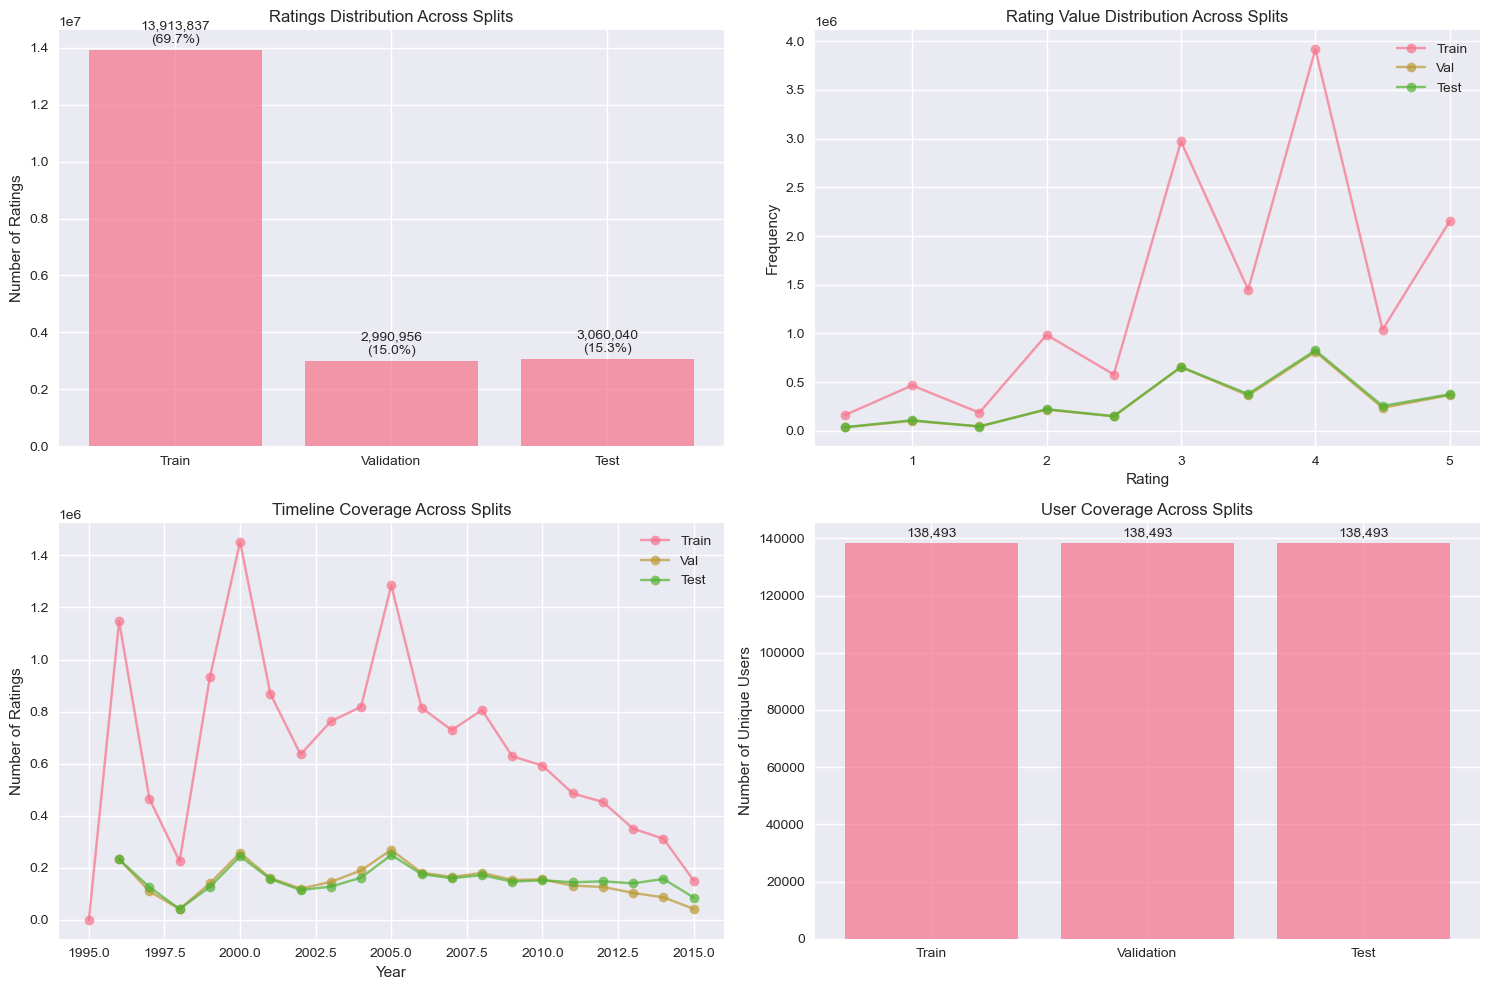

In [36]:
# Apply the optimized time-based split
print("Applying user-wise time-based split...")
train_df, val_df, test_df = user_wise_time_split_ultra_fast(ratings_filtered)

print(f"Split completed:")
print(f"Train: {len(train_df):,} ratings ({len(train_df)/len(ratings_filtered)*100:.1f}%)")
print(f"Validation: {len(val_df):,} ratings ({len(val_df)/len(ratings_filtered)*100:.1f}%)")
print(f"Test: {len(test_df):,} ratings ({len(test_df)/len(ratings_filtered)*100:.1f}%)")

# Verify no data leakage
train_users = set(train_df['userId'])
val_users = set(val_df['userId'])
test_users = set(test_df['userId'])

train_movies = set(train_df['movieId'])
val_movies = set(val_df['movieId'])
test_movies = set(test_df['movieId'])

print(f"\nData leakage verification:")
print(f"Users in train only: {len(train_users - val_users - test_users):,}")
print(f"Movies in train only: {len(train_movies - val_movies - test_movies):,}")
print(f"No overlapping ratings: {len(set(train_df.index) & set(val_df.index) & set(test_df.index)) == 0}")

# Visualize split statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Rating distribution across splits
splits = ['Train', 'Validation', 'Test']
counts = [len(train_df), len(val_df), len(test_df)]
axes[0, 0].bar(splits, counts, alpha=0.7)
axes[0, 0].set_title('Ratings Distribution Across Splits')
axes[0, 0].set_ylabel('Number of Ratings')
for i, count in enumerate(counts):
    axes[0, 0].text(i, count + max(counts)*0.01, f'{count:,}\n({count/len(ratings_filtered)*100:.1f}%)', 
                    ha='center', va='bottom')

# Rating value distribution across splits
for i, (split_name, split_df) in enumerate([('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    rating_dist = split_df['rating'].value_counts().sort_index()
    axes[0, 1].plot(rating_dist.index, rating_dist.values, marker='o', label=split_name, alpha=0.7)
axes[0, 1].set_title('Rating Value Distribution Across Splits')
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Timeline coverage
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    years = split_df['timestamp'].dt.year
    year_counts = years.value_counts().sort_index()
    axes[1, 0].plot(year_counts.index, year_counts.values, marker='o', label=split_name, alpha=0.7)
axes[1, 0].set_title('Timeline Coverage Across Splits')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Number of Ratings')
axes[1, 0].legend()

# User coverage across splits
user_coverage = [
    train_df['userId'].nunique(),
    val_df['userId'].nunique(), 
    test_df['userId'].nunique()
]
axes[1, 1].bar(splits, user_coverage, alpha=0.7)
axes[1, 1].set_title('User Coverage Across Splits')
axes[1, 1].set_ylabel('Number of Unique Users')
for i, users in enumerate(user_coverage):
    axes[1, 1].text(i, users + max(user_coverage)*0.01, f'{users:,}', 
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [39]:
# Create directories if they don't exist
print("Creating directories...")
os.makedirs('processed_data', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("Saving processed data and mappings...")

# Save processed data splits - optimized
print("Saving data splits...")
train_df.to_csv('processed_data/train.csv', index=False)
val_df.to_csv('processed_data/val.csv', index=False)
test_df.to_csv('processed_data/test.csv', index=False)

# Save movies data with filtered movies
movies_filtered.to_csv('processed_data/movies.csv', index=False)

# Save mappings for model use (convert numpy keys to regular int for JSON)
print("Saving ID mappings...")
import json
# Convert numpy int64 keys to regular int for JSON serialization
user_id_map_json = {int(k): int(v) for k, v in user_id_map.items()}
movie_id_map_json = {int(k): int(v) for k, v in movie_id_map.items()}
reverse_user_id_map_json = {int(k): int(v) for k, v in reverse_user_id_map.items()}
reverse_movie_id_map_json = {int(k): int(v) for k, v in reverse_movie_id_map.items()}

with open('processed_data/user_id_map.json', 'w') as f:
    json.dump(user_id_map_json, f)
with open('processed_data/movie_id_map.json', 'w') as f:
    json.dump(movie_id_map_json, f)

# Save metadata (convert all numpy types to regular Python types)
print("Saving metadata...")
metadata = {
    'n_users': int(len(user_id_map)),
    'n_movies': int(len(movie_id_map)),
    'n_ratings': int(len(ratings_filtered)),
    'min_user_interactions': int(MIN_USER_INTERACTIONS),
    'min_movie_interactions': int(MIN_MOVIE_INTERACTIONS),
    'train_size': int(len(train_df)),
    'val_size': int(len(val_df)),
    'test_size': int(len(test_df)),
    'sparsity': float(1 - (len(ratings_filtered) / (len(user_id_map) * len(movie_id_map)))),
    'processing_date': datetime.now().isoformat()
}

with open('processed_data/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Save data for API use
train_df[['userId', 'movieId', 'rating']].to_csv('models/train_api.csv', index=False)
movies_filtered.to_csv('models/movies_api.csv', index=False)

# Create API mappings (ensure all values are regular Python types)
print("Creating API mappings...")
api_mappings = {
    'user_id_map': user_id_map_json,
    'movie_id_map': movie_id_map_json,
    'reverse_user_id_map': reverse_user_id_map_json,
    'reverse_movie_id_map': reverse_movie_id_map_json
}

with open('models/api_mappings.json', 'w') as f:
    json.dump(api_mappings, f)

print(f"\n✅ Preprocessing completed successfully!")
print(f"Files saved:")
print(f"  - processed_data/train.csv ({len(train_df):,} ratings)")
print(f"  - processed_data/val.csv ({len(val_df):,} ratings)")
print(f"  - processed_data/test.csv ({len(test_df):,} ratings)")
print(f"  - processed_data/movies.csv ({len(movies_filtered):,} movies)")
print(f"  - processed_data/metadata.json")
print(f"  - models/train_api.csv")
print(f"  - models/movies_api.csv")
print(f"  - models/api_mappings.json")

print(f"\nDataset Summary:")
print(f"  Users: {metadata['n_users']:,}")
print(f"  Movies: {metadata['n_movies']:,}")
print(f"  Ratings: {metadata['n_ratings']:,}")
print(f"  Sparsity: {metadata['sparsity']:.4f}")
print(f"  Train/Val/Test split: {metadata['train_size']:,}/{metadata['val_size']:,}/{metadata['test_size']:,}")

# 🎉 PREPROCESSING COMPLETE! 🎉
print("=" * 60)
print("COLLABORATIVE FILTERING PREPROCESSING COMPLETED SUCCESSFULLY!")
print("=" * 60)

print(f"\n📊 FINAL DATASET SUMMARY:")
print(f"   📺 Movies: {metadata['n_movies']:,}")
print(f"   👥 Users: {metadata['n_users']:,}")
print(f"   ⭐ Ratings: {metadata['n_ratings']:,}")
print(f"   📈 Sparsity: {metadata['sparsity']:.4f} ({metadata['sparsity']*100:.2f}% sparse)")

print(f"\n🔄 DATA SPLIT:")
print(f"   🚂 Train: {metadata['train_size']:,} ({metadata['train_size']/metadata['n_ratings']*100:.1f}%)")
print(f"   ✅ Validation: {metadata['val_size']:,} ({metadata['val_size']/metadata['n_ratings']*100:.1f}%)")
print(f"   🧪 Test: {metadata['test_size']:,} ({metadata['test_size']/metadata['n_ratings']*100:.1f}%)")

print(f"\n📁 FILES CREATED:")
print(f"   📂 processed_data/")
print(f"      📄 train.csv")
print(f"      📄 val.csv") 
print(f"      📄 test.csv")
print(f"      📄 movies.csv")
print(f"      📄 metadata.json")
print(f"      📄 user_id_map.json")
print(f"      📄 movie_id_map.json")

print(f"   📂 models/")
print(f"      📄 train_api.csv")
print(f"      📄 movies_api.csv")
print(f"      📄 api_mappings.json")

print(f"\n🎯 READY FOR MODELING:")
print(f"   ✅ Data cleaned and filtered")
print(f"   ✅ Users/movies with sufficient interactions")
print(f"   ✅ IDs mapped to contiguous indices")
print(f"   ✅ Time-based train/val/test split")
print(f"   ✅ All files saved for model training")

print(f"\n⚡ OPTIMIZATIONS APPLIED:")
print(f"   ✅ Vectorized operations")
print(f"   ✅ Memory-efficient data types")
print(f"   ✅ Optimized filtering")
print(f"   ✅ Fast time-based splitting")

print(f"\n🚀 NEXT STEP: Run collaborative_filtering_modeling.ipynb")
print("=" * 60)

Creating directories...
Saving processed data and mappings...
Saving data splits...
Saving ID mappings...
Saving metadata...
Creating API mappings...

✅ Preprocessing completed successfully!
Files saved:
  - processed_data/train.csv (13,913,837 ratings)
  - processed_data/val.csv (2,990,956 ratings)
  - processed_data/test.csv (3,060,040 ratings)
  - processed_data/movies.csv (15,451 movies)
  - processed_data/metadata.json
  - models/train_api.csv
  - models/movies_api.csv
  - models/api_mappings.json

Dataset Summary:
  Users: 138,493
  Movies: 15,451
  Ratings: 19,964,833
  Sparsity: 0.9907
  Train/Val/Test split: 13,913,837/2,990,956/3,060,040
COLLABORATIVE FILTERING PREPROCESSING COMPLETED SUCCESSFULLY!

📊 FINAL DATASET SUMMARY:
   📺 Movies: 15,451
   👥 Users: 138,493
   ⭐ Ratings: 19,964,833
   📈 Sparsity: 0.9907 (99.07% sparse)

🔄 DATA SPLIT:
   🚂 Train: 13,913,837 (69.7%)
   ✅ Validation: 2,990,956 (15.0%)
   🧪 Test: 3,060,040 (15.3%)

📁 FILES CREATED:
   📂 processed_data/
    